In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"C:\Users\rpap9\OneDrive\Desktop\ML Project\IRIS - IRIS.csv")

In [3]:
df.head()

,sepal-length,sepal-width,petal-length,petal-width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal-length  150 non-null    float64
 1   sepal-width   150 non-null    float64
 2   petal-length  150 non-null    float64
 3   petal-width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
print("\n---  Checking for Missing Values ---")
print("Missing values per column:")
print(df.isnull().sum())
if df.isnull().sum().sum() == 0:
    print("No missing values found.")


---  Checking for Missing Values ---
Missing values per column:
sepal-length    0
sepal-width     0
petal-length    0
petal-width     0
species         0
dtype: int64
No missing values found.



--- Target Variable Distribution ---
Distribution of species:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


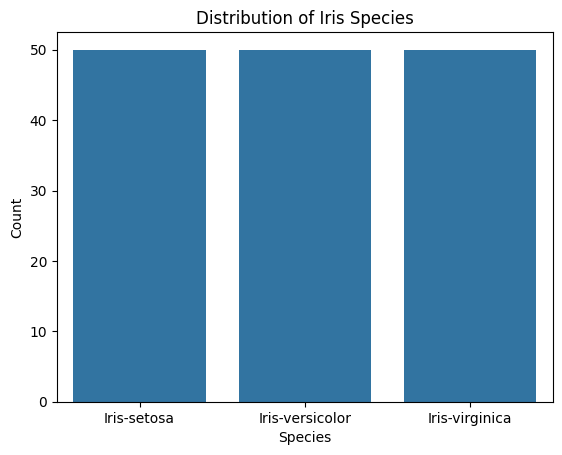

The dataset appears to be balanced across the three species.


In [6]:
print("\n--- Target Variable Distribution ---")
print("Distribution of species:")
print(df['species'].value_counts())
sns.countplot(x='species', data=df)
plt.title('Distribution of Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()
print("The dataset appears to be balanced across the three species.")


--- Feature Relationships and Distributions ---
Generating Pairplot (colored by species)...


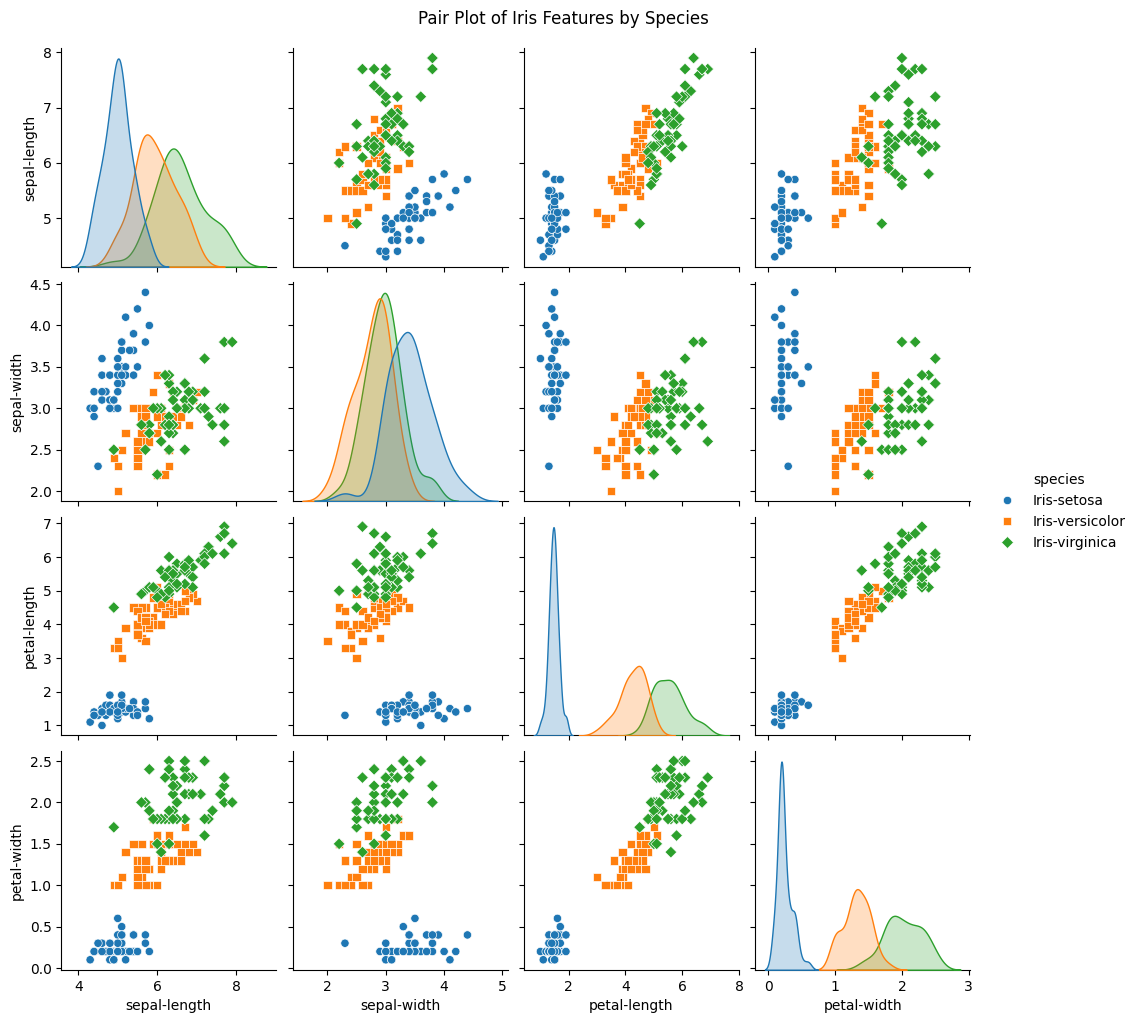

Pairplot shows potential separability between species based on features, especially petal length/width.


In [7]:
print("\n--- Feature Relationships and Distributions ---")

# Pairplot to visualize relationships between all pairs of features, colored by species
print("Generating Pairplot (colored by species)...")
sns.pairplot(df, hue='species', markers=["o", "s", "D"])
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02)
plt.show()
print("Pairplot shows potential separability between species based on features, especially petal length/width.")


Generating Boxplots for each feature by species...


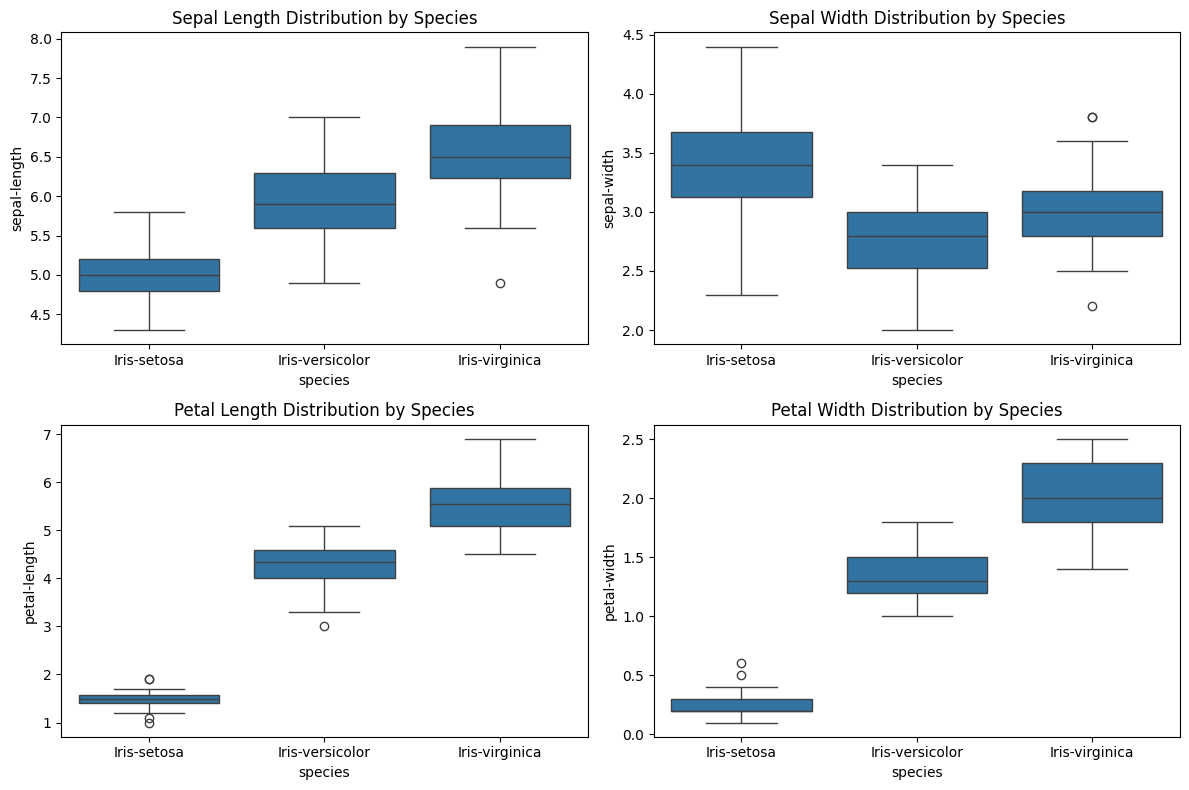

Boxplots highlight differences in feature medians and distributions across species.

EDA Complete.



In [8]:
# Boxplots to see feature distributions per species
print("\nGenerating Boxplots for each feature by species...")
features = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width']
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=feature, data=df)
    plt.title(f'{feature.replace("-", " ").title()} Distribution by Species')
plt.tight_layout()
plt.show()
print("Boxplots highlight differences in feature medians and distributions across species.")
print("\nEDA Complete.\n")

In [9]:
print("--- Step 4: Data Pre-processing ---")

# 4.1 Separate Features (X) and Target (y)
print("--- Separating Features and Target ---")
X = df.drop('species', axis=1)
y = df['species']
print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())
print("\nUnique target labels before encoding:", y.unique())

--- Step 4: Data Pre-processing ---
--- Separating Features and Target ---
Features (X) head:
   sepal-length  sepal-width  petal-length  petal-width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target (y) head:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object

Unique target labels before encoding: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [10]:
print("\n--- Encoding Target Variable ---")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Store the mapping for later use in reports
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Target labels after encoding:", np.unique(y_encoded))
print("Label mapping:", label_mapping)
# Show the first few encoded labels
print("Encoded target (y_encoded) head:", y_encoded[:5])


--- Encoding Target Variable ---
Target labels after encoding: [0 1 2]
Label mapping: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}
Encoded target (y_encoded) head: [0 0 0 0 0]


In [11]:
print("\n---Splitting Data into Training and Testing Sets ---")
# Use stratify=y_encoded to ensure proportion of classes is same in train and test sets
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nDistribution in Training Set:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nDistribution in Test Set:")
print(pd.Series(y_test).value_counts(normalize=True))


---Splitting Data into Training and Testing Sets ---
Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)

Distribution in Training Set:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64

Distribution in Test Set:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


In [12]:
print("\n--- Scaling Numerical Features (StandardScaler) ---")
# SVMs are sensitive to feature scales, so scaling is crucial.
scaler = StandardScaler()

# Display data BEFORE scaling
print("\nX_train BEFORE scaling (first 5 rows):")
print(X_train.head())

# Fit the scaler on the training data ONLY and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use transform only, no fitting on test data!

# Display data AFTER scaling (converting back to DataFrame for readability)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
print("\nX_train AFTER scaling (first 5 rows):")
print(X_train_scaled_df.head())
print("Features are now centered around 0 with unit variance.")
print("\nPre-processing Complete.\n")


--- Scaling Numerical Features (StandardScaler) ---

X_train BEFORE scaling (first 5 rows):
     sepal-length  sepal-width  petal-length  petal-width
8             4.4          2.9           1.4          0.2
106           4.9          2.5           4.5          1.7
76            6.8          2.8           4.8          1.4
9             4.9          3.1           1.5          0.1
89            5.5          2.5           4.0          1.3

X_train AFTER scaling (first 5 rows):
     sepal-length  sepal-width  petal-length  petal-width
8       -1.721568    -0.324840     -1.347036    -1.320168
106     -1.124492    -1.226129      0.414290     0.651867
76       1.144395    -0.550162      0.584741     0.257460
9       -1.124492     0.125805     -1.290219    -1.451638
89      -0.408002    -1.226129      0.130206     0.125991
Features are now centered around 0 with unit variance.

Pre-processing Complete.



In [14]:
print("--- Training Initial SVM Model (Default Parameters) ---")
# Instantiate the SVM Classifier with default parameters
# Using probability=True allows getting probability estimates later if needed, but slightly slower.
# random_state for reproducibility if the algorithm has stochastic elements (less relevant for basic SVC).
svm_model_initial = SVC(random_state=42, probability=True)

# Train the model
print("Training the initial SVM model...")
svm_model_initial.fit(X_train_scaled, y_train)
print("Initial SVM model trained successfully.")

--- Training Initial SVM Model (Default Parameters) ---
Training the initial SVM model...
Initial SVM model trained successfully.


--- Evaluating the Initial SVM Model ---
Initial Model Accuracy: 0.9667

Initial Model Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Initial Model Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


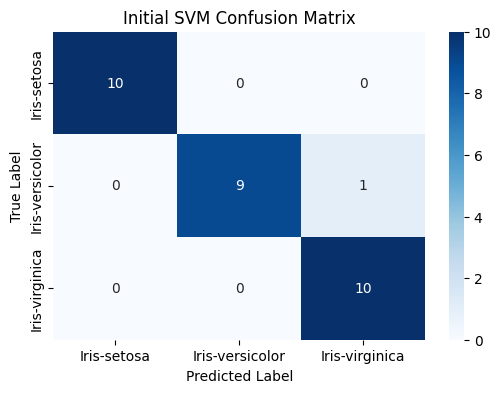

In [15]:
print("--- Evaluating the Initial SVM Model ---")

# Make predictions on the scaled test data
y_pred_initial = svm_model_initial.predict(X_test_scaled)

# Calculate accuracy
accuracy_initial = accuracy_score(y_test, y_pred_initial)
print(f"Initial Model Accuracy: {accuracy_initial:.4f}")

# Generate Classification Report
print("\nInitial Model Classification Report:")
# Use target_names to show original class labels
target_names = le.classes_
print(classification_report(y_test, y_pred_initial, target_names=target_names))

# Generate and Visualize Confusion Matrix
print("\nInitial Model Confusion Matrix:")
cm_initial = confusion_matrix(y_test, y_pred_initial)
print(cm_initial)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_initial, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Initial SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [16]:
print("--- Hyperparameter Tuning using GridSearchCV ---")
param_grid = {
    'C': [0.1, 1, 10, 100],              # Regularization strength
    'gamma': [1, 0.1, 0.01, 0.001],      # Kernel coefficient for 'rbf'
    'kernel': ['rbf', 'linear']         # Types of kernels to try
}


print(f"Starting GridSearchCV with {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])} combinations...")
grid_search = GridSearchCV(SVC(random_state=42, probability=True),
                           param_grid,
                           refit=True,
                           verbose=1,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and the best score
print("\nGridSearchCV finished.")
print("Best Parameters found by GridSearchCV:")
print(grid_search.best_params_)
print(f"\nBest cross-validation accuracy score: {grid_search.best_score_:.4f}")

# The best estimator is automatically stored in grid_search.best_estimator_
best_svm_model = grid_search.best_estimator_
print("\nHyperparameter tuning complete.\n")

--- Hyperparameter Tuning using GridSearchCV ---
Starting GridSearchCV with 32 combinations...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

GridSearchCV finished.
Best Parameters found by GridSearchCV:
{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Best cross-validation accuracy score: 0.9833

Hyperparameter tuning complete.



---Evaluating the Tuned SVM Model ---
Tuned Model Accuracy: 0.9667
Improvement over initial model: 0.0000

Tuned Model Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Tuned Model Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


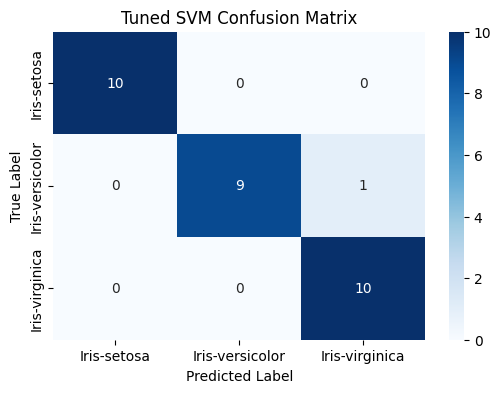

Tuned model evaluation complete.



In [17]:
print("---Evaluating the Tuned SVM Model ---")

# Make predictions using the best model found by GridSearchCV
y_pred_tuned = best_svm_model.predict(X_test_scaled)
# Or equivalently: y_pred_tuned = grid_search.predict(X_test_scaled) because refit=True

# Calculate accuracy
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")

# Compare with initial accuracy
print(f"Improvement over initial model: {accuracy_tuned - accuracy_initial:.4f}")

# Generate Classification Report for the tuned model
print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=target_names))

# Generate and Visualize Confusion Matrix for the tuned model
print("\nTuned Model Confusion Matrix:")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print(cm_tuned)

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Tuned SVM Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
print("Tuned model evaluation complete.\n")

In [19]:
print("--- Step 9: Conclusion ---")
print(f"The initial SVM model achieved an accuracy of {accuracy_initial:.4f}.")
print(f"After hyperparameter tuning using GridSearchCV, the best parameters found were {grid_search.best_params_}.")
print(f"The tuned SVM model achieved an accuracy of {accuracy_tuned:.4f} on the test set.")

if accuracy_tuned > 0.90:
    print("\nThe tuned model successfully achieved an accuracy greater than 90%.")
    if accuracy_tuned == 1.0:
        print("The model achieved perfect accuracy on the test set for this split!")
    elif accuracy_tuned > accuracy_initial:
         print(f"Tuning improved the accuracy by {accuracy_tuned - accuracy_initial:.4f}.")
    elif accuracy_tuned == accuracy_initial:
         print("Tuning resulted in the same accuracy as the default model for this split.")
    else:
         print("Interestingly, tuning resulted in slightly lower accuracy than the default model for this split. This can sometimes happen due to the specific train/test split or if default parameters were already near optimal.")

else:
    print("\nThe tuned model did not achieve an accuracy greater than 90% on this specific test set.")

--- Step 9: Conclusion ---
The initial SVM model achieved an accuracy of 0.9667.
After hyperparameter tuning using GridSearchCV, the best parameters found were {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}.
The tuned SVM model achieved an accuracy of 0.9667 on the test set.

The tuned model successfully achieved an accuracy greater than 90%.
Tuning resulted in the same accuracy as the default model for this split.
